# AutoSPECTRA — Week 3 Notebook
## Window Generation, Chronological Splitting, Leakage Controls and Model-Ready Representations

**Module:** Advanced Artificial Intelligence Projects in Data Science (55-710603)  
**Project:** AutoSPECTRA — Deep-Learning Intrusion Detection for the Connected Car  
**Group:** 7  
**Week:** 3 of 8

This notebook records the third weekly GitHub milestone. It reuses the validated Week 2 DLC-aware parser and adds the model-ready data preparation required before baseline training.

## Week 3 Scope

- Convert chronological CAN traffic into non-overlapping 64-frame windows.
- Create Normal, DoS, Fuzzy, Gear and RPM window labels.
- Sample candidate windows across the full duration of every source capture.
- Apply source-aware and class-aware chronological partitioning.
- Protect the held-out test split from model development.
- Confirm that all five classes occur in training, validation and test data.
- Engineer 24 tabular window features.
- Build a `64 × 11` sequential representation.
- Build a `64 × 64` recurrence-style image representation.
- Record split metadata and leakage checks.
- Export small Week 3 evidence files.

## Team Contributions

| Member | Name | Role | Week 3 Contribution |
|---|---|---|---|
| 1 | Amit Das | Windowing, Split & Integration Lead | Implemented 64-frame non-overlapping windows, source/class chronological partitioning, versioned cache generation and the integrated Week 3 notebook |
| 2 | Aahmad Sayeed | Recurrence Representation Lead | Validated the `64 × 64` recurrence-image transformation and reviewed class-specific visual examples for later CNN training |
| 3 | Maheswari Kamireddy | Sequence Representation Lead | Validated the `64 × 11` chronological sequence tensor, payload padding, timing channel and later LSTM/autoencoder input contract |
| 4 | Miftha Thahniyath | Metadata & Data-Lineage Lead | Defined the window metadata required for later incident reports, Flask outputs, traceability and demonstration evidence |
| 5 | Nagireddy Nakka | Leakage, Ethics & Reproducibility Lead | Reviewed temporal leakage controls, held-out test protection, class balancing, dataset limitations and Week 3 reproducibility evidence |

## Eight-Week Development Plan

| Week | Technical Evidence |
|---|---|
| Week 1 | Repository setup, research problem, architecture, roles and ethics baseline |
| Week 2 | Dataset acquisition, DLC-aware parser, source audit and initial EDA |
| **Week 3** | **Windowing, chronological split, leakage checks and feature representations** |
| Week 4 | Logistic Regression, Random Forest, Extra Trees and XGBoost baselines |
| Week 5 | Recurrence-image encoder and CNN |
| Week 6 | Bidirectional LSTM and LSTM autoencoder |
| Week 7 | Fusion, calibration, ablation, latency, error analysis and responsible AI |
| Week 8 | Incident reports, Flask application, live demonstration and final reproducibility package |

## Week 3 Boundary

This notebook does **not** train Logistic Regression, Random Forest, Extra Trees, XGBoost, CNN, LSTM or the autoencoder. Model training begins in Week 4.

## Kaggle Instructions

1. Open Kaggle and create a notebook.
2. Select **Add Input**.
3. Attach `pranavjha24/car-hacking-dataset`.
4. Upload this notebook.
5. Run all cells from top to bottom.

Week 3 outputs are written to:

```text
/kaggle/working/autospectra_week03_outputs
```

The first run scans the complete source captures and creates a versioned processed cache. Later runs can load the cache.

In [4]:
# 1. Imports and reproducibility

import os
import gc
import json
import math
import time
import random
import hashlib
import platform
import warnings
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.3.3


## 2. Week 3 Configuration

The primary experiment uses 64-frame windows and a stride of 64. Therefore, neighbouring samples do not share CAN frames.

The split strategy is versioned as:

```text
source_class_chronological_v3
```

The strategy samples candidate windows across the complete duration of every source/class group before applying chronological 70%/15%/15% partitions.

In [5]:
# 2. Experiment configuration


FAST_MODE = True

WINDOW_SIZE = 64
STRIDE = 64                 # Non-overlapping windows: prevents frame leakage.
CHUNK_SIZE = 400_000
TRAIN_FRACTION = 0.70
VALID_FRACTION = 0.15
TEST_FRACTION = 0.15
MIN_ATTACK_FRAMES = 1

# Versioned strategy name is included in the cache hash. Therefore this
# corrected notebook cannot accidentally load the old normal-only test cache.
SPLIT_STRATEGY = "source_class_chronological_v3"
REBUILD_CACHE = False

if FAST_MODE:
    MAX_WINDOWS_PER_CLASS = {
        "train": 3_500,
        "validation": 800,
        "test": 800,
    }
    CLASSIFIER_EPOCHS = 8
    AUTOENCODER_EPOCHS = 8
    BATCH_SIZE = 256
    RF_TREES = 220
    ET_TREES = 220
    XGB_TREES = 260
else:
    MAX_WINDOWS_PER_CLASS = {
        "train": 12_000,
        "validation": 2_500,
        "test": 2_500,
    }
    CLASSIFIER_EPOCHS = 15
    AUTOENCODER_EPOCHS = 12
    BATCH_SIZE = 256
    RF_TREES = 400
    ET_TREES = 400
    XGB_TREES = 500

# Each source/class reservoir must be large enough to supply all three
# chronological partitions before the final per-class balancing step.
GROUP_RESERVOIR_CAPACITY = (
    sum(MAX_WINDOWS_PER_CLASS.values()) + 256
)

LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 3
RUN_XGBOOST = False
RUN_DEEP_LEARNING = False
RUN_AUTOENCODER = False
RUN_FEATURE_ABLATION = False
RUN_EXPENSIVE_WINDOW_ABLATION = False

OUTPUT_DIR = Path("/kaggle/working/autospectra_week03_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = OUTPUT_DIR / "plots"
MODEL_DIR = OUTPUT_DIR / "models"
REPORT_DIR = OUTPUT_DIR / "reports"
for directory in (PLOT_DIR, MODEL_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["Normal", "DoS", "Fuzzy", "Gear", "RPM"]
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}
INDEX_TO_CLASS = {index: name for name, index in CLASS_TO_INDEX.items()}

SOURCE_FILES = {
    "DoS": "DoS_dataset.csv",
    "Fuzzy": "Fuzzy_dataset.csv",
    "Gear": "gear_dataset.csv",
    "RPM": "RPM_dataset.csv",
}

FEATURE_NAMES = [
    "duration_s",
    "message_rate_hz",
    "iat_mean_ms",
    "iat_std_ms",
    "iat_p95_ms",
    "iat_max_ms",
    "unique_id_count",
    "id_entropy",
    "max_id_ratio",
    "id_transition_rate",
    "can_id_mean_norm",
    "can_id_std_norm",
    "dominant_id_norm",
    "zero_id_ratio",
    "dlc_mean",
    "dlc_std",
    "payload_mean",
    "payload_std",
    "payload_entropy",
    "nonzero_byte_ratio",
    "byte_change_mean",
    "byte_change_std",
    "payload_sum_mean",
    "payload_sum_std",
]

CONFIG_FOR_CACHE = {
    "split_strategy": SPLIT_STRATEGY,
    "fast_mode": FAST_MODE,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "max_windows": MAX_WINDOWS_PER_CLASS,
    "group_reservoir_capacity": GROUP_RESERVOIR_CAPACITY,
    "min_attack_frames": MIN_ATTACK_FRAMES,
}
CONFIG_HASH = hashlib.md5(
    json.dumps(CONFIG_FOR_CACHE, sort_keys=True).encode("utf-8")
).hexdigest()[:10]

CACHE_FILE = OUTPUT_DIR / f"window_cache_{CONFIG_HASH}.npz"
CACHE_META_FILE = OUTPUT_DIR / f"window_metadata_{CONFIG_HASH}.csv"

print(json.dumps(CONFIG_FOR_CACHE, indent=2))
print("Corrected cache:", CACHE_FILE)

{
  "split_strategy": "source_class_chronological_v3",
  "fast_mode": true,
  "window_size": 64,
  "stride": 64,
  "max_windows": {
    "train": 3500,
    "validation": 800,
    "test": 800
  },
  "group_reservoir_capacity": 5356,
  "min_attack_frames": 1
}
Corrected cache: /kaggle/working/autospectra_week03_outputs/window_cache_a6bed9825e.npz


## 3. Locate the HCRL Source Captures

The Week 2 parser is reused. The required files are:

```text
DoS_dataset.csv
Fuzzy_dataset.csv
gear_dataset.csv
RPM_dataset.csv
```

Normal windows are created from legitimate `R` frames inside the four attack captures. The optional independent normal capture is reported but is not mixed into the principal five-class split.

In [6]:

# 3. Dataset discovery


def locate_dataset_files(search_root: str = "/kaggle/input"):
    """Find the four expected HCRL Car-Hacking files anywhere below Kaggle input."""
    found = {}
    optional_normal = None

    for root, _, files in os.walk(search_root):
        lower_to_original = {filename.lower(): filename for filename in files}

        for attack_name, expected_filename in SOURCE_FILES.items():
            key = expected_filename.lower()
            if key in lower_to_original:
                found[attack_name] = Path(root) / lower_to_original[key]

        if "normal_run_data.txt" in lower_to_original:
            optional_normal = Path(root) / lower_to_original["normal_run_data.txt"]

    missing = sorted(set(SOURCE_FILES) - set(found))
    if missing:
        raise FileNotFoundError(
            "Missing required files for: "
            + ", ".join(missing)
            + ". Attach Kaggle dataset 'pranavjha24/car-hacking-dataset'."
        )

    return found, optional_normal

DATA_FILES, OPTIONAL_NORMAL_FILE = locate_dataset_files()

file_table = []
for attack_name, path in DATA_FILES.items():
    file_table.append({
        "Capture": attack_name,
        "Filename": path.name,
        "Path": str(path),
        "Size_MB": path.stat().st_size / (1024 ** 2),
    })

display(pd.DataFrame(file_table).sort_values("Capture"))
print("Optional normal file:", OPTIONAL_NORMAL_FILE)

,Capture,Filename,Path,Size_MB
0,DoS,DoS_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,181.254108
1,Fuzzy,Fuzzy_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,189.324157
2,Gear,gear_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,219.650663
3,RPM,RPM_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,228.483139


Optional normal file: /kaggle/input/datasets/pranavjha24/car-hacking-dataset/normal_run_data.txt


## 4. Window Builder and Feature Engineering

The Week 3 implementation adds the following behaviour to the Week 2 parser:

1. Stream each source capture in chronological order.
2. Create 64-frame candidate windows.
3. Advance by 64 frames, preventing shared-frame overlap.
4. Assign Normal when no injected frame is present.
5. Assign the source attack class when at least one `T` frame is present.
6. Store a bounded reservoir for every source/class combination.
7. Retain the original global row position.
8. Sort each source/class reservoir chronologically.
9. Partition it into 70% training, 15% validation and 15% test.
10. Apply balancing only after the chronological partitions exist.

The test set is not used for feature design, threshold selection or model selection.

In [7]:

# 4. Raw parsing, feature engineering, and corrected split builder


RAW_COLUMNS = ["Timestamp", "CAN_ID", "DLC"] + [f"X{i}" for i in range(9)]

# Hash-map conversion is faster than repeatedly calling int(text, 16)
# for millions of payload values.
HEX_BYTE_MAP = {}
for value in range(256):
    for key in {
        f"{value:02x}", f"{value:02X}",
        f"{value:x}", f"{value:X}",
    }:
        HEX_BYTE_MAP[key] = value

CAN_ID_MAP = {}
for value in range(0x800):
    for key in {
        f"{value:04x}", f"{value:04X}",
        f"{value:03x}", f"{value:03X}",
        f"{value:x}", f"{value:X}",
    }:
        CAN_ID_MAP[key] = value


def fast_line_count(path: Path) -> int:
    """Count rows with buffered binary reads."""
    with path.open("rb") as handle:
        return sum(1 for _ in handle)


def shannon_entropy(values: np.ndarray) -> float:
    """Shannon entropy in bits for a one-dimensional integer array."""
    _, counts = np.unique(values, return_counts=True)
    probabilities = counts / max(counts.sum(), 1)
    return float(
        -(probabilities * np.log2(probabilities + 1e-12)).sum()
    )


def convert_chunk(chunk: pd.DataFrame):
    """
    Convert one flexible-width HCRL raw chunk into compact NumPy arrays.

    The attack flag is not in a fixed column: it occurs immediately after
    the number of bytes specified by DLC. Missing payload positions remain 0.
    """
    chunk = chunk.dropna(
        subset=["Timestamp", "CAN_ID", "DLC"]
    ).copy()

    timestamps = pd.to_numeric(
        chunk["Timestamp"], errors="coerce"
    ).to_numpy(np.float64)

    dlc = (
        pd.to_numeric(chunk["DLC"], errors="coerce")
        .fillna(0)
        .clip(0, 8)
        .to_numpy(np.uint8)
    )

    can_text = chunk["CAN_ID"].astype(str).str.strip()
    can_ids_series = can_text.map(CAN_ID_MAP)

    missing_ids = can_ids_series.isna()
    if missing_ids.any():
        can_ids_series.loc[missing_ids] = (
            can_text.loc[missing_ids]
            .apply(lambda value: int(value, 16))
        )

    can_ids = (
        can_ids_series
        .fillna(0)
        .clip(0, 0x7FF)
        .to_numpy(np.uint16)
    )

    payload = np.zeros(
        (len(chunk), 8),
        dtype=np.uint8,
    )

    for byte_index in range(8):
        text = (
            chunk[f"X{byte_index}"]
            .astype(str)
            .str.strip()
        )
        numeric = (
            text.map(HEX_BYTE_MAP)
            .fillna(0)
            .clip(0, 255)
            .to_numpy(np.uint16)
        )
        valid = dlc > byte_index
        payload[valid, byte_index] = (
            numeric[valid].astype(np.uint8)
        )

    is_attack = np.zeros(
        len(chunk),
        dtype=bool,
    )

    for dlc_value in range(9):
        mask = dlc == dlc_value
        if not mask.any():
            continue

        flag_text = (
            chunk[f"X{dlc_value}"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        is_attack[mask] = (
            flag_text[mask]
            .eq("T")
            .to_numpy()
        )

    valid_timestamp = np.isfinite(timestamps)

    return (
        timestamps[valid_timestamp],
        can_ids[valid_timestamp],
        dlc[valid_timestamp],
        payload[valid_timestamp],
        is_attack[valid_timestamp],
    )


def build_sequence(
    timestamps,
    can_ids,
    dlc,
    payload,
) -> np.ndarray:
    """
    Create the 64 x 11 sequence used by the CNN and LSTM.

    Channels:
      0    CAN ID / 2047
      1    DLC / 8
      2-9  payload bytes / 255
      10   log-scaled inter-arrival time
    """
    deltas = np.diff(
        timestamps,
        prepend=timestamps[0],
    )
    deltas = np.clip(deltas, 0, None)

    sequence = np.zeros(
        (len(timestamps), 11),
        dtype=np.float32,
    )

    sequence[:, 0] = np.clip(
        can_ids.astype(np.float32) / 2047.0,
        0,
        1,
    )
    sequence[:, 1] = (
        dlc.astype(np.float32) / 8.0
    )
    sequence[:, 2:10] = (
        payload.astype(np.float32) / 255.0
    )
    sequence[:, 10] = np.clip(
        np.log1p(deltas * 1_000_000.0) / 15.0,
        0,
        1,
    )

    return sequence.astype(np.float16)


def build_tabular_features(
    timestamps,
    can_ids,
    dlc,
    payload,
) -> np.ndarray:
    """Engineer window features without flags, labels, or future values."""
    duration = max(
        float(timestamps[-1] - timestamps[0]),
        1e-9,
    )

    deltas = np.diff(timestamps)
    positive_deltas = np.clip(
        deltas,
        0,
        None,
    )
    iat_ms = positive_deltas * 1000.0

    unique_ids, id_counts = np.unique(
        can_ids,
        return_counts=True,
    )
    dominant_position = int(
        np.argmax(id_counts)
    )
    dominant_id = int(
        unique_ids[dominant_position]
    )
    max_id_ratio = float(
        id_counts[dominant_position]
        / len(can_ids)
    )

    payload_flat = payload.reshape(-1)

    if len(payload) > 1:
        payload_differences = np.abs(
            np.diff(
                payload.astype(np.float32),
                axis=0,
            )
        ).mean(axis=1)
    else:
        payload_differences = np.array(
            [0.0],
            dtype=np.float32,
        )

    payload_sums = (
        payload.sum(axis=1)
        .astype(np.float32)
    )

    return np.array([
        duration,
        len(timestamps) / duration,
        float(iat_ms.mean()) if len(iat_ms) else 0.0,
        float(iat_ms.std()) if len(iat_ms) else 0.0,
        float(np.percentile(iat_ms, 95)) if len(iat_ms) else 0.0,
        float(iat_ms.max()) if len(iat_ms) else 0.0,
        len(unique_ids),
        shannon_entropy(can_ids),
        max_id_ratio,
        (
            float(np.mean(can_ids[1:] != can_ids[:-1]))
            if len(can_ids) > 1
            else 0.0
        ),
        float(can_ids.mean() / 2047.0),
        float(can_ids.std() / 2047.0),
        dominant_id / 2047.0,
        float(np.mean(can_ids == 0)),
        float(dlc.mean()),
        float(dlc.std()),
        float(payload.mean()),
        float(payload.std()),
        shannon_entropy(payload_flat),
        float(np.mean(payload_flat != 0)),
        float(payload_differences.mean()),
        float(payload_differences.std()),
        float(payload_sums.mean()),
        float(payload_sums.std()),
    ], dtype=np.float32)


class Reservoir:
    """Deterministic fixed-capacity reservoir sampler."""

    def __init__(
        self,
        capacity: int,
        seed: int,
    ):
        self.capacity = int(capacity)
        self.rng = np.random.default_rng(seed)
        self.seen = 0
        self.items = []

    def choose_slot(self):
        self.seen += 1

        if len(self.items) < self.capacity:
            return len(self.items)

        candidate = int(
            self.rng.integers(0, self.seen)
        )

        return (
            candidate
            if candidate < self.capacity
            else None
        )

    def store(
        self,
        slot: int,
        item: dict,
    ):
        if slot == len(self.items):
            self.items.append(item)
        else:
            self.items[slot] = item


def make_reservoirs():
    """
    Keep separate reservoirs for each source capture and each label.

    This is the core correction: sampling occurs across the full capture
    before any split is assigned. Consequently, later attack windows remain
    available for validation and testing.
    """
    reservoirs = {}

    for source_index, source_attack in enumerate(SOURCE_FILES):
        reservoirs[source_attack] = {}

        for local_index, class_name in enumerate(
            ["Normal", source_attack]
        ):
            reservoirs[source_attack][class_name] = Reservoir(
                GROUP_RESERVOIR_CAPACITY,
                SEED
                + source_index * 100
                + local_index,
            )

    return reservoirs


def process_capture(
    path: Path,
    source_attack: str,
    total_rows: int,
    reservoirs: dict,
    chunk_size: int = CHUNK_SIZE,
):
    """
    Stream one full capture and create non-overlapping candidate windows.

    No train/validation/test decision is made here. Windows are first sampled
    across the entire source/class timeline and split later.
    """
    print(
        f"\nProcessing {source_attack}: "
        f"{path.name} ({total_rows:,} rows)"
    )

    carry = None
    carry_global_start = 0
    global_chunk_start = 0
    next_window_start = 0
    processed_windows = 0
    accepted_windows = 0

    reader = pd.read_csv(
        path,
        header=None,
        names=RAW_COLUMNS,
        dtype=str,
        chunksize=chunk_size,
        engine="c",
        on_bad_lines="skip",
    )

    for chunk_number, chunk in enumerate(
        reader,
        start=1,
    ):
        (
            timestamps,
            can_ids,
            dlc,
            payload,
            flags,
        ) = convert_chunk(chunk)

        current_length = len(timestamps)

        if carry is None:
            combined = (
                timestamps,
                can_ids,
                dlc,
                payload,
                flags,
            )
            combined_global_start = (
                global_chunk_start
            )
        else:
            combined = (
                np.concatenate(
                    [carry[0], timestamps]
                ),
                np.concatenate(
                    [carry[1], can_ids]
                ),
                np.concatenate(
                    [carry[2], dlc]
                ),
                np.concatenate(
                    [carry[3], payload],
                    axis=0,
                ),
                np.concatenate(
                    [carry[4], flags]
                ),
            )
            combined_global_start = (
                carry_global_start
            )

        combined_end_global = (
            combined_global_start
            + len(combined[0])
        )

        if next_window_start < combined_global_start:
            next_window_start = (
                combined_global_start
            )

        while (
            next_window_start + WINDOW_SIZE
            <= combined_end_global
        ):
            local_start = (
                next_window_start
                - combined_global_start
            )
            local_end = (
                local_start + WINDOW_SIZE
            )

            window_flags = combined[4][
                local_start:local_end
            ]
            attack_count = int(
                window_flags.sum()
            )

            if attack_count >= MIN_ATTACK_FRAMES:
                class_name = source_attack
                first_attack_position = int(
                    np.flatnonzero(
                        window_flags
                    )[0]
                )
            else:
                class_name = "Normal"
                first_attack_position = -1

            reservoir = reservoirs[
                source_attack
            ][class_name]

            selected_slot = (
                reservoir.choose_slot()
            )

            if selected_slot is not None:
                win_ts = combined[0][
                    local_start:local_end
                ]
                win_ids = combined[1][
                    local_start:local_end
                ]
                win_dlc = combined[2][
                    local_start:local_end
                ]
                win_payload = combined[3][
                    local_start:local_end
                ]

                features = build_tabular_features(
                    win_ts,
                    win_ids,
                    win_dlc,
                    win_payload,
                )
                sequence = build_sequence(
                    win_ts,
                    win_ids,
                    win_dlc,
                    win_payload,
                )

                if first_attack_position >= 0:
                    latency_upper_bound_ms = float(
                        (
                            win_ts[-1]
                            - win_ts[
                                first_attack_position
                            ]
                        )
                        * 1000.0
                    )
                else:
                    latency_upper_bound_ms = np.nan

                unique_ids, counts = np.unique(
                    win_ids,
                    return_counts=True,
                )
                dominant_id = int(
                    unique_ids[
                        np.argmax(counts)
                    ]
                )

                item = {
                    "sequence": sequence,
                    "features": features,
                    "label": CLASS_TO_INDEX[
                        class_name
                    ],
                    "metadata": {
                        "split": "unassigned",
                        "class_name": class_name,
                        "source_capture": source_attack,
                        "start_timestamp":
                            float(win_ts[0]),
                        "end_timestamp":
                            float(win_ts[-1]),
                        "global_start_row":
                            int(next_window_start),
                        "attack_frame_count":
                            attack_count,
                        "attack_ratio":
                            attack_count / WINDOW_SIZE,
                        "first_attack_position":
                            first_attack_position,
                        "latency_upper_bound_ms":
                            latency_upper_bound_ms,
                        "dominant_can_id":
                            dominant_id,
                        "dominant_can_id_hex":
                            f"0x{dominant_id:03X}",
                    },
                }

                reservoir.store(
                    selected_slot,
                    item,
                )
                accepted_windows += 1

            processed_windows += 1
            next_window_start += STRIDE

        keep = min(
            WINDOW_SIZE - 1,
            len(combined[0]),
        )

        carry = (
            combined[0][-keep:].copy(),
            combined[1][-keep:].copy(),
            combined[2][-keep:].copy(),
            combined[3][-keep:].copy(),
            combined[4][-keep:].copy(),
        )
        carry_global_start = (
            combined_end_global - keep
        )
        global_chunk_start += current_length

        if chunk_number % 5 == 0:
            print(
                f"  chunk {chunk_number:>2} | "
                f"rows read {global_chunk_start:,} | "
                f"candidate windows "
                f"{processed_windows:,} | "
                f"reservoir writes "
                f"{accepted_windows:,}"
            )

        del (
            chunk,
            timestamps,
            can_ids,
            dlc,
            payload,
            flags,
            combined,
        )
        gc.collect()

    print(
        f"Finished {source_attack}: "
        f"{processed_windows:,} candidate windows, "
        f"{accepted_windows:,} reservoir writes."
    )


def chronological_partition(
    items,
):
    """
    Divide one source/class group chronologically.

    Because windows are non-overlapping, boundaries do not share CAN frames.
    At least one item is retained in every split when the group has >= 3.
    """
    items = sorted(
        items,
        key=lambda item:
            item["metadata"]["global_start_row"],
    )

    number_of_items = len(items)

    if number_of_items < 3:
        raise RuntimeError(
            "A source/class group has fewer than three sampled "
            f"windows ({number_of_items}); cannot form all splits."
        )

    train_count = max(
        1,
        int(
            math.floor(
                number_of_items
                * TRAIN_FRACTION
            )
        ),
    )

    validation_count = max(
        1,
        int(
            math.floor(
                number_of_items
                * VALID_FRACTION
            )
        ),
    )

    # Reserve at least one item for test.
    if (
        train_count
        + validation_count
        >= number_of_items
    ):
        validation_count = max(
            1,
            number_of_items
            - train_count
            - 1,
        )

    if (
        train_count
        + validation_count
        >= number_of_items
    ):
        train_count = max(
            1,
            number_of_items
            - validation_count
            - 1,
        )

    train_end = train_count
    validation_end = (
        train_count + validation_count
    )

    partitions = {
        "train": items[:train_end],
        "validation":
            items[train_end:validation_end],
        "test":
            items[validation_end:],
    }

    if any(
        len(partition) == 0
        for partition in partitions.values()
    ):
        raise RuntimeError(
            "Chronological partition created an empty split."
        )

    return partitions


def deterministic_cap(
    items,
    capacity,
    seed,
):
    """Select a reproducible subset while retaining broad time coverage."""
    if len(items) <= capacity:
        return list(items)

    ordered = sorted(
        items,
        key=lambda item: (
            item["metadata"]["source_capture"],
            item["metadata"]["global_start_row"],
        ),
    )

    # Evenly spaced selection gives coverage across the complete period
    # instead of concentrating on one short interval.
    positions = np.linspace(
        0,
        len(ordered) - 1,
        num=capacity,
        dtype=int,
    )

    return [
        ordered[position]
        for position in positions
    ]


def finalise_reservoirs(
    reservoirs,
):
    """
    Build balanced train/validation/test arrays with every class present.

    Splitting is chronological inside each source/class group. Final caps are
    applied only after these partitions have been formed.
    """
    grouped_split_items = {
        split_name: {
            class_name: []
            for class_name in CLASS_NAMES
        }
        for split_name in [
            "train",
            "validation",
            "test",
        ]
    }

    group_summary = []

    for source_attack in SOURCE_FILES:
        for class_name in [
            "Normal",
            source_attack,
        ]:
            group_items = reservoirs[
                source_attack
            ][class_name].items

            partitions = chronological_partition(
                group_items
            )

            group_summary.append({
                "Source_Capture":
                    source_attack,
                "Class":
                    class_name,
                "Sampled_Total":
                    len(group_items),
                "Train":
                    len(partitions["train"]),
                "Validation":
                    len(partitions["validation"]),
                "Test":
                    len(partitions["test"]),
            })

            for (
                split_name,
                split_items,
            ) in partitions.items():
                for item in split_items:
                    item["metadata"][
                        "split"
                    ] = split_name

                grouped_split_items[
                    split_name
                ][class_name].extend(
                    split_items
                )

    group_summary_df = pd.DataFrame(
        group_summary
    )
    print(
        "\nSource/class chronological "
        "partition summary:"
    )
    display(group_summary_df)

    output = {}

    for split_index, split_name in enumerate(
        ["train", "validation", "test"]
    ):
        selected_items = []

        for class_index, class_name in enumerate(
            CLASS_NAMES
        ):
            class_items = grouped_split_items[
                split_name
            ][class_name]

            if not class_items:
                raise RuntimeError(
                    f"No {class_name} windows were available "
                    f"for split '{split_name}'."
                )

            class_items = deterministic_cap(
                class_items,
                MAX_WINDOWS_PER_CLASS[
                    split_name
                ],
                SEED
                + split_index * 100
                + class_index,
            )

            selected_items.extend(
                class_items
            )

        rng = np.random.default_rng(
            SEED + split_index
        )
        rng.shuffle(selected_items)

        sequences = np.stack([
            item["sequence"]
            for item in selected_items
        ]).astype(np.float16)

        features = np.stack([
            item["features"]
            for item in selected_items
        ]).astype(np.float32)

        labels = np.array([
            item["label"]
            for item in selected_items
        ], dtype=np.int64)

        metadata = pd.DataFrame([
            item["metadata"]
            for item in selected_items
        ])

        output[split_name] = {
            "sequences": sequences,
            "features": features,
            "labels": labels,
            "metadata": metadata,
        }

    return output


## 5. Build or Load the Week 3 Cache

The cache stores:

- 24-feature tabular matrices;
- `64 × 11` sequences;
- integer class labels;
- window-level metadata;
- split assignment;
- source capture;
- original start-row position;
- attack-frame count and ratio;
- first attack position;
- estimated window-completion latency;
- dominant CAN ID.

The configuration hash prevents an old split from being loaded accidentally.

In [8]:

# 5. Build/load cache


def save_window_cache(data):
    np.savez_compressed(
        CACHE_FILE,
        train_sequences=data["train"]["sequences"],
        train_features=data["train"]["features"],
        train_labels=data["train"]["labels"],
        validation_sequences=data["validation"]["sequences"],
        validation_features=data["validation"]["features"],
        validation_labels=data["validation"]["labels"],
        test_sequences=data["test"]["sequences"],
        test_features=data["test"]["features"],
        test_labels=data["test"]["labels"],
    )

    metadata_frames = []

    for split_name in ["train", "validation", "test"]:
        frame = data[split_name]["metadata"].copy()
        frame["cache_split"] = split_name
        frame["cache_row"] = np.arange(len(frame))
        metadata_frames.append(frame)

    pd.concat(
        metadata_frames, ignore_index=True
    ).to_csv(CACHE_META_FILE, index=False)

    with (
        OUTPUT_DIR / f"config_{CONFIG_HASH}.json"
    ).open("w") as handle:
        json.dump(CONFIG_FOR_CACHE, handle, indent=2)


def load_window_cache():
    arrays = np.load(CACHE_FILE, allow_pickle=False)
    metadata = pd.read_csv(CACHE_META_FILE)

    data = {}

    for split_name in ["train", "validation", "test"]:
        split_metadata = (
            metadata[
                metadata["cache_split"] == split_name
            ]
            .sort_values("cache_row")
            .reset_index(drop=True)
        )

        data[split_name] = {
            "sequences":
                arrays[f"{split_name}_sequences"],
            "features":
                arrays[f"{split_name}_features"],
            "labels":
                arrays[f"{split_name}_labels"],
            "metadata": split_metadata,
        }

    return data


if (
    CACHE_FILE.exists()
    and CACHE_META_FILE.exists()
    and not REBUILD_CACHE
):
    print("Loading corrected source/class chronological cache...")
    DATA = load_window_cache()
else:
    print("Counting rows before corrected source/class chronological extraction...")

    ROW_COUNTS = {
        attack_name: fast_line_count(path)
        for attack_name, path in DATA_FILES.items()
    }

    display(pd.DataFrame([
        {"Capture": name, "Rows": count}
        for name, count in ROW_COUNTS.items()
    ]))

    reservoirs = make_reservoirs()

    for source_attack, path in DATA_FILES.items():
        process_capture(
            path=path,
            source_attack=source_attack,
            total_rows=ROW_COUNTS[source_attack],
            reservoirs=reservoirs,
        )

    DATA = finalise_reservoirs(reservoirs)
    save_window_cache(DATA)


for split_name, split_data in DATA.items():
    print(
        split_name,
        "| sequences:", split_data["sequences"].shape,
        "| features:", split_data["features"].shape,
        "| labels:", split_data["labels"].shape,
    )

Counting rows before corrected source/class chronological extraction...


,Capture,Rows
0,DoS,3665771
1,Fuzzy,3838860
2,Gear,4443142
3,RPM,4621702



Processing DoS: DoS_dataset.csv (3,665,771 rows)
  chunk  5 | rows read 2,000,000 | candidate windows 31,250 | reservoir writes 22,039
  chunk 10 | rows read 3,665,771 | candidate windows 57,277 | reservoir writes 27,748
Finished DoS: 57,277 candidate windows, 27,748 reservoir writes.

Processing Fuzzy: Fuzzy_dataset.csv (3,838,860 rows)
  chunk  5 | rows read 2,000,000 | candidate windows 31,250 | reservoir writes 22,176
  chunk 10 | rows read 3,838,860 | candidate windows 59,982 | reservoir writes 28,614
Finished Fuzzy: 59,982 candidate windows, 28,614 reservoir writes.

Processing Gear: gear_dataset.csv (4,443,142 rows)
  chunk  5 | rows read 2,000,000 | candidate windows 31,250 | reservoir writes 22,252
  chunk 10 | rows read 4,000,000 | candidate windows 62,500 | reservoir writes 29,695
Finished Gear: 69,424 candidate windows, 30,746 reservoir writes.

Processing RPM: RPM_dataset.csv (4,621,702 rows)
  chunk  5 | rows read 2,000,000 | candidate windows 31,250 | reservoir writes 2

,Source_Capture,Class,Sampled_Total,Train,Validation,Test
0,DoS,Normal,5356,3749,803,804
1,DoS,DoS,5356,3749,803,804
2,Fuzzy,Normal,5356,3749,803,804
3,Fuzzy,Fuzzy,5356,3749,803,804
4,Gear,Normal,5356,3749,803,804
5,Gear,Gear,5356,3749,803,804
6,RPM,Normal,5356,3749,803,804
7,RPM,RPM,5356,3749,803,804


train | sequences: (17500, 64, 11) | features: (17500, 24) | labels: (17500,)
validation | sequences: (4000, 64, 11) | features: (4000, 24) | labels: (4000,)
test | sequences: (4000, 64, 11) | features: (4000, 24) | labels: (4000,)


# Part A — Split, Coverage and Leakage Audit

In [9]:
# Validate class coverage and confirm that labels are never features.
summary_rows = []

for split_name in [
    "train",
    "validation",
    "test",
]:
    counts = (
        pd.Series(
            DATA[split_name]["labels"]
        )
        .value_counts()
        .sort_index()
    )

    for (
        class_index,
        class_name,
    ) in enumerate(CLASS_NAMES):
        summary_rows.append({
            "Split": split_name,
            "Class": class_name,
            "Windows": int(
                counts.get(
                    class_index,
                    0,
                )
            ),
        })

split_class_counts = pd.DataFrame(
    summary_rows
)

coverage_table = (
    split_class_counts
    .pivot(
        index="Class",
        columns="Split",
        values="Windows",
    )
    .reindex(CLASS_NAMES)
    .fillna(0)
    .astype(int)
)

display(coverage_table)

missing_pairs = [
    f"{class_name} in {split_name}"
    for class_name in CLASS_NAMES
    for split_name in [
        "train",
        "validation",
        "test",
    ]
    if coverage_table.loc[
        class_name,
        split_name,
    ] == 0
]

if missing_pairs:
    raise RuntimeError(
        "Invalid class coverage: "
        + ", ".join(missing_pairs)
        + ". Delete old caches or set REBUILD_CACHE=True, "
        "then rerun from the configuration cell."
    )

expected_class_indices = set(
    range(len(CLASS_NAMES))
)

for split_name in [
    "train",
    "validation",
    "test",
]:
    observed = set(
        np.unique(
            DATA[split_name]["labels"]
        )
    )

    if observed != expected_class_indices:
        raise RuntimeError(
            f"Split '{split_name}' contains labels "
            f"{sorted(observed)}, expected "
            f"{sorted(expected_class_indices)}."
        )

assert (
    DATA["train"]["features"].shape[1]
    == len(FEATURE_NAMES)
)

assert not any(
    "label" in name.lower()
    or "flag" in name.lower()
    or "attack_frame" in name.lower()
    for name in FEATURE_NAMES
)

assert STRIDE >= WINDOW_SIZE, (
    "Use non-overlapping windows to avoid shared-frame leakage."
)

print(
    "Coverage audit passed: all five classes occur in "
    "train, validation, and unseen test sets."
)
print(
    "Feature audit passed: no target or attack-flag feature "
    "is used by any model."
)


Split,test,train,validation
Class,,,
Normal,800,3500,800
DoS,800,3500,800
Fuzzy,800,3500,800
Gear,800,3500,800
RPM,800,3500,800


Coverage audit passed: all five classes occur in train, validation, and unseen test sets.
Feature audit passed: no target or attack-flag feature is used by any model.


In [10]:
# 6. Source/class chronological-boundary audit

chronology_rows = []
chronology_failures = []

for source_capture in SOURCE_FILES:
    for class_name in ["Normal", source_capture]:
        split_stats = {}

        for split_name in ["train", "validation", "test"]:
            metadata = DATA[split_name]["metadata"]
            subset = metadata[
                (metadata["source_capture"] == source_capture)
                & (metadata["class_name"] == class_name)
            ].copy()

            if len(subset):
                split_stats[split_name] = {
                    "count": int(len(subset)),
                    "min_start": int(subset["global_start_row"].min()),
                    "max_start": int(subset["global_start_row"].max()),
                }
            else:
                split_stats[split_name] = {
                    "count": 0,
                    "min_start": np.nan,
                    "max_start": np.nan,
                }

        chronological = True

        if all(split_stats[name]["count"] > 0 for name in split_stats):
            chronological = (
                split_stats["train"]["max_start"]
                < split_stats["validation"]["min_start"]
                < split_stats["test"]["min_start"]
            )

        chronology_rows.append({
            "Source_Capture": source_capture,
            "Class": class_name,
            "Train_Count": split_stats["train"]["count"],
            "Train_Min_Row": split_stats["train"]["min_start"],
            "Train_Max_Row": split_stats["train"]["max_start"],
            "Validation_Count": split_stats["validation"]["count"],
            "Validation_Min_Row": split_stats["validation"]["min_start"],
            "Validation_Max_Row": split_stats["validation"]["max_start"],
            "Test_Count": split_stats["test"]["count"],
            "Test_Min_Row": split_stats["test"]["min_start"],
            "Test_Max_Row": split_stats["test"]["max_start"],
            "Chronological_Order_Passed": chronological,
        })

        if not chronological:
            chronology_failures.append(
                f"{source_capture}/{class_name}"
            )

chronology_audit_df = pd.DataFrame(chronology_rows)
display(chronology_audit_df)

if chronology_failures:
    raise RuntimeError(
        "Chronological split boundary failure: "
        + ", ".join(chronology_failures)
    )

print("Chronological boundary audit passed for every source/class group.")

,Source_Capture,Class,Train_Count,Train_Min_Row,Train_Max_Row,Validation_Count,Validation_Min_Row,Validation_Max_Row,Test_Count,Test_Min_Row,Test_Max_Row,Chronological_Order_Passed
0,DoS,Normal,875,128,2891840,200,2892480,3288704,200,3291584,3664256,True
1,DoS,DoS,3500,1600,1884544,800,1885056,2288256,800,2288896,2675264,True
2,Fuzzy,Normal,875,0,3078336,200,3079168,3467712,200,3468288,3837696,True
3,Fuzzy,Fuzzy,3500,1728,1901696,800,1907264,2453504,800,2459072,2929920,True
4,Gear,Normal,875,960,3691008,200,3692160,4065408,200,4066496,4442560,True
5,Gear,Gear,3500,3584,2456384,800,2457024,3020736,800,3021760,3527936,True
6,RPM,Normal,875,1216,3875968,200,3876928,4262336,200,4263424,4621376,True
7,RPM,RPM,3500,1856,2613888,800,2614016,3148224,800,3148672,3710464,True


Chronological boundary audit passed for every source/class group.


In [11]:
# 7. Non-overlap and duplicate-start audit

overlap_rows = []
duplicate_failures = []

for split_name in ["train", "validation", "test"]:
    metadata = DATA[split_name]["metadata"]

    duplicate_count = int(
        metadata.duplicated(
            subset=["source_capture", "global_start_row"]
        ).sum()
    )

    if duplicate_count:
        duplicate_failures.append(
            f"{split_name}: {duplicate_count} duplicate starts"
        )

    for source_capture in SOURCE_FILES:
        subset = (
            metadata[
                metadata["source_capture"] == source_capture
            ]
            .sort_values("global_start_row")
        )

        starts = subset["global_start_row"].to_numpy()
        minimum_gap = (
            int(np.diff(starts).min())
            if len(starts) > 1
            else np.nan
        )

        overlap_rows.append({
            "Split": split_name,
            "Source_Capture": source_capture,
            "Windows": int(len(subset)),
            "Minimum_Start_Row_Gap": minimum_gap,
            "Expected_Minimum_Gap": WINDOW_SIZE,
            "Non_Overlap_Passed": (
                True
                if len(starts) <= 1
                else bool(minimum_gap >= WINDOW_SIZE)
            ),
        })

overlap_audit_df = pd.DataFrame(overlap_rows)
display(overlap_audit_df)

if duplicate_failures:
    raise RuntimeError(
        "Duplicate window starts detected: "
        + "; ".join(duplicate_failures)
    )

if not overlap_audit_df["Non_Overlap_Passed"].all():
    raise RuntimeError("Shared-frame overlap detected.")

print("Non-overlap audit passed.")

,Split,Source_Capture,Windows,Minimum_Start_Row_Gap,Expected_Minimum_Gap,Non_Overlap_Passed
0,train,DoS,4375,64,64,True
1,train,Fuzzy,4375,64,64,True
2,train,Gear,4375,64,64,True
3,train,RPM,4375,64,64,True
4,validation,DoS,1000,64,64,True
5,validation,Fuzzy,1000,64,64,True
6,validation,Gear,1000,64,64,True
7,validation,RPM,1000,64,64,True
8,test,DoS,1000,64,64,True
9,test,Fuzzy,1000,64,64,True


Non-overlap audit passed.


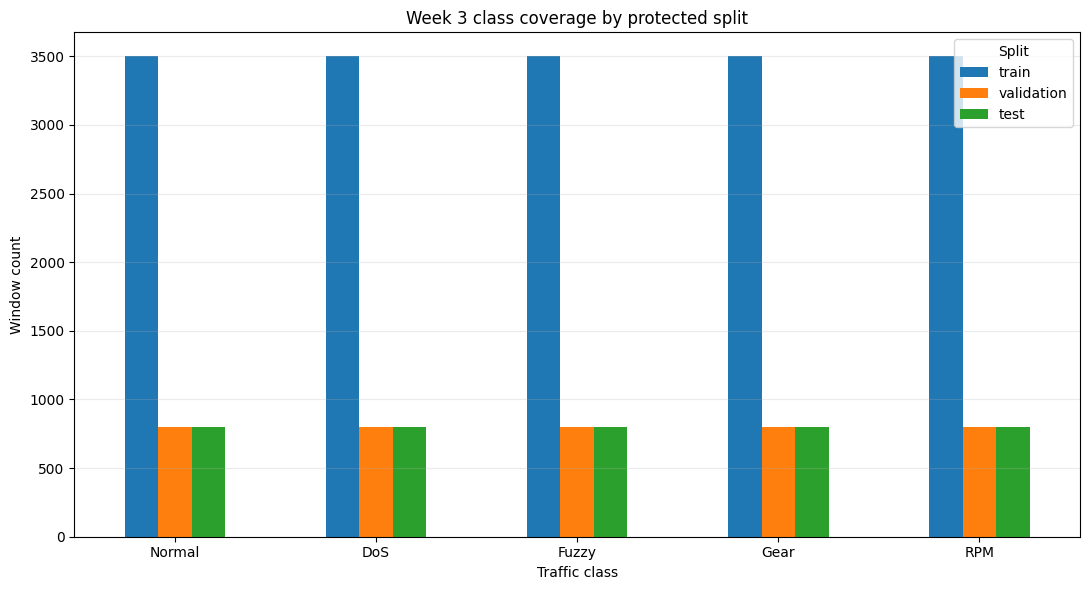

In [12]:
# 8. Visualise class balance across the three protected splits

split_order = ["train", "validation", "test"]

plot_table = (
    split_class_counts
    .pivot(index="Class", columns="Split", values="Windows")
    .reindex(CLASS_NAMES)
    .reindex(columns=split_order)
)

fig, ax = plt.subplots(figsize=(11, 6))
plot_table.plot(kind="bar", ax=ax)
ax.set_title("Week 3 class coverage by protected split")
ax.set_xlabel("Traffic class")
ax.set_ylabel("Window count")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "week03_class_coverage.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

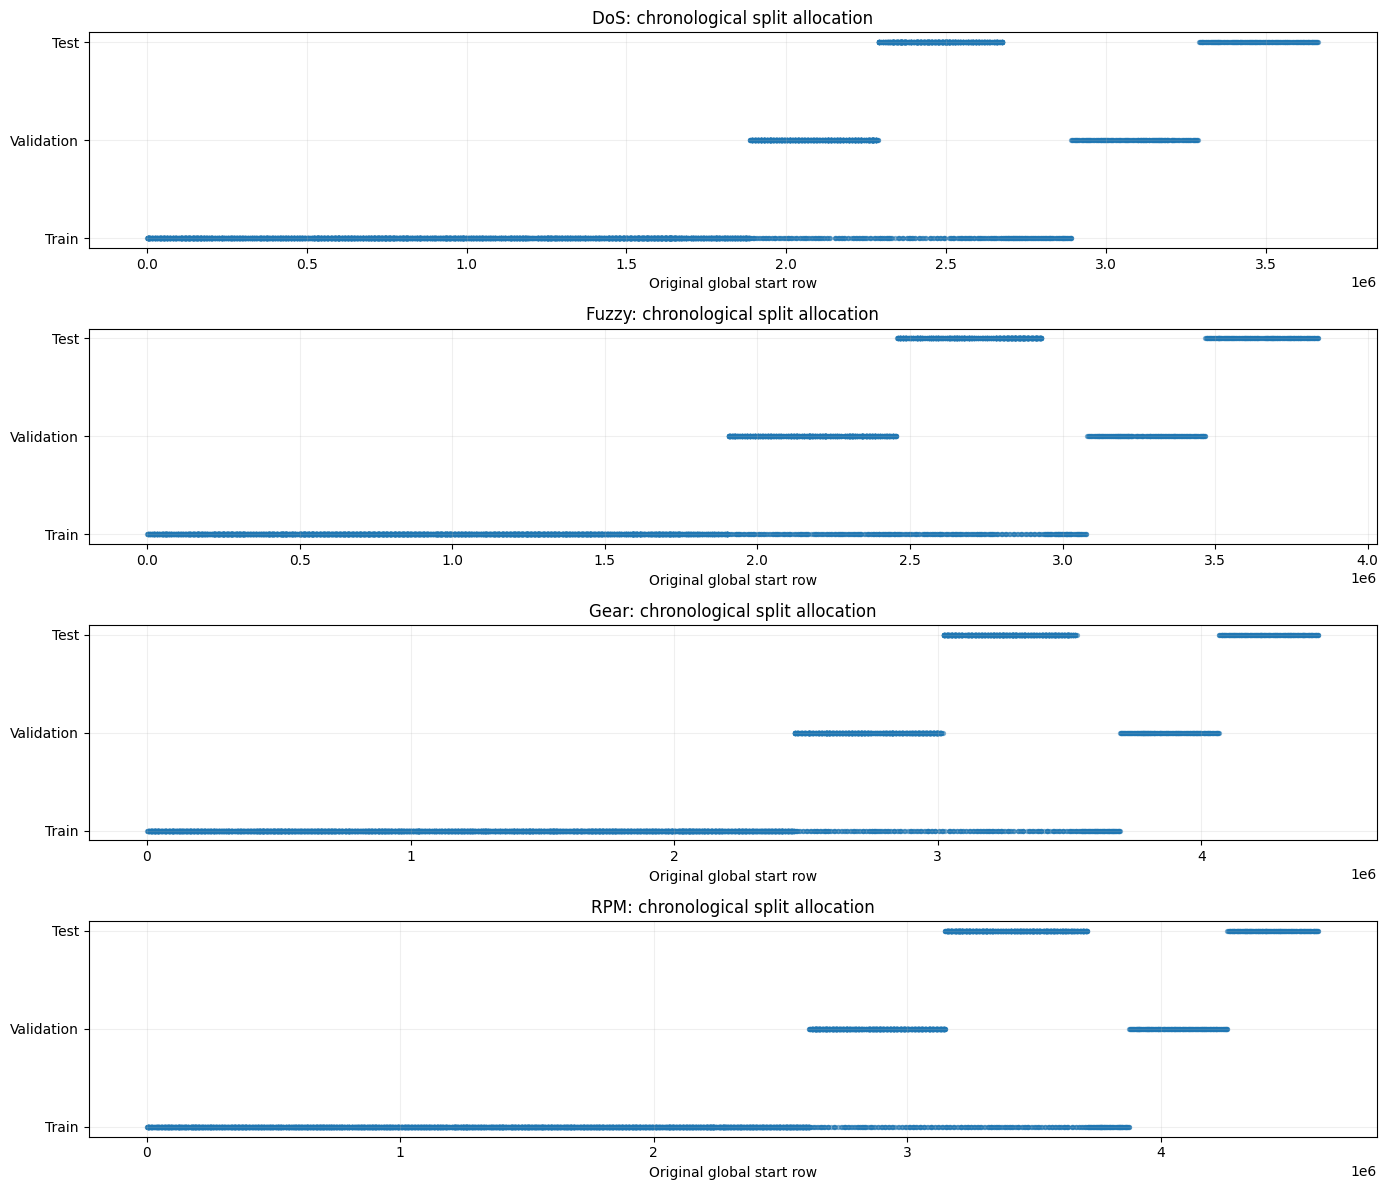

In [13]:
# 9. Visualise chronological split boundaries by source capture

fig, axes = plt.subplots(
    len(SOURCE_FILES),
    1,
    figsize=(14, 12),
    sharex=False,
)

split_marker = {
    "train": 0,
    "validation": 1,
    "test": 2,
}

for axis, source_capture in zip(axes, SOURCE_FILES):
    pieces = []

    for split_name in ["train", "validation", "test"]:
        metadata = DATA[split_name]["metadata"]
        subset = metadata[
            metadata["source_capture"] == source_capture
        ][
            ["global_start_row", "class_name"]
        ].copy()

        subset["split"] = split_name
        subset["split_index"] = split_marker[split_name]
        pieces.append(subset)

    timeline = pd.concat(pieces, ignore_index=True)

    axis.scatter(
        timeline["global_start_row"],
        timeline["split_index"],
        s=8,
        alpha=0.5,
    )

    axis.set_title(f"{source_capture}: chronological split allocation")
    axis.set_yticks([0, 1, 2])
    axis.set_yticklabels(["Train", "Validation", "Test"])
    axis.set_xlabel("Original global start row")
    axis.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    PLOT_DIR / "week03_split_timeline.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

# Part B — Model-Ready Representations

In [14]:
# 10. Representation-shape and numerical-range audit

representation_rows = []

for split_name in ["train", "validation", "test"]:
    sequences = DATA[split_name]["sequences"]
    features = DATA[split_name]["features"]
    labels = DATA[split_name]["labels"]

    representation_rows.append({
        "Split": split_name,
        "Windows": int(len(labels)),
        "Sequence_Shape": str(tuple(sequences.shape)),
        "Feature_Shape": str(tuple(features.shape)),
        "Label_Shape": str(tuple(labels.shape)),
        "Sequence_Min": float(sequences.min()),
        "Sequence_Max": float(sequences.max()),
        "Feature_Finite": bool(np.isfinite(features).all()),
    })

    assert sequences.shape[1:] == (WINDOW_SIZE, 11)
    assert features.shape[1] == 24
    assert len(sequences) == len(features) == len(labels)
    assert sequences.min() >= 0
    assert sequences.max() <= 1
    assert np.isfinite(features).all()

representation_audit_df = pd.DataFrame(representation_rows)
display(representation_audit_df)

print("Representation audit passed.")

,Split,Windows,Sequence_Shape,Feature_Shape,Label_Shape,Sequence_Min,Sequence_Max,Feature_Finite
0,train,17500,"(17500, 64, 11)","(17500, 24)","(17500,)",0.0,1.0,True
1,validation,4000,"(4000, 64, 11)","(4000, 24)","(4000,)",0.0,1.0,True
2,test,4000,"(4000, 64, 11)","(4000, 24)","(4000,)",0.0,1.0,True


Representation audit passed.


In [15]:
# 11. Feature dictionary

feature_groups = {
    "duration_s": "Timing",
    "message_rate_hz": "Timing",
    "iat_mean_ms": "Timing",
    "iat_std_ms": "Timing",
    "iat_p95_ms": "Timing",
    "iat_max_ms": "Timing",
    "unique_id_count": "CAN ID",
    "id_entropy": "CAN ID",
    "max_id_ratio": "CAN ID",
    "id_transition_rate": "CAN ID",
    "can_id_mean_norm": "CAN ID",
    "can_id_std_norm": "CAN ID",
    "dominant_id_norm": "CAN ID",
    "zero_id_ratio": "CAN ID",
    "dlc_mean": "DLC",
    "dlc_std": "DLC",
    "payload_mean": "Payload",
    "payload_std": "Payload",
    "payload_entropy": "Payload",
    "nonzero_byte_ratio": "Payload",
    "byte_change_mean": "Payload",
    "byte_change_std": "Payload",
    "payload_sum_mean": "Payload",
    "payload_sum_std": "Payload",
}

feature_dictionary_df = pd.DataFrame({
    "Feature_Index": np.arange(len(FEATURE_NAMES)),
    "Feature": FEATURE_NAMES,
    "Group": [feature_groups[name] for name in FEATURE_NAMES],
})

display(feature_dictionary_df)

assert len(feature_dictionary_df) == 24

,Feature_Index,Feature,Group
0,0,duration_s,Timing
1,1,message_rate_hz,Timing
2,2,iat_mean_ms,Timing
3,3,iat_std_ms,Timing
4,4,iat_p95_ms,Timing
5,5,iat_max_ms,Timing
6,6,unique_id_count,CAN ID
7,7,id_entropy,CAN ID
8,8,max_id_ratio,CAN ID
9,9,id_transition_rate,CAN ID


In [16]:
# 12. Sequence-channel dictionary

sequence_channel_df = pd.DataFrame([
    {"Channel": 0, "Name": "CAN_ID", "Scaling": "value / 2047"},
    {"Channel": 1, "Name": "DLC", "Scaling": "value / 8"},
    {"Channel": 2, "Name": "DATA_0", "Scaling": "value / 255"},
    {"Channel": 3, "Name": "DATA_1", "Scaling": "value / 255"},
    {"Channel": 4, "Name": "DATA_2", "Scaling": "value / 255"},
    {"Channel": 5, "Name": "DATA_3", "Scaling": "value / 255"},
    {"Channel": 6, "Name": "DATA_4", "Scaling": "value / 255"},
    {"Channel": 7, "Name": "DATA_5", "Scaling": "value / 255"},
    {"Channel": 8, "Name": "DATA_6", "Scaling": "value / 255"},
    {"Channel": 9, "Name": "DATA_7", "Scaling": "value / 255"},
    {
        "Channel": 10,
        "Name": "Inter_Arrival_Time",
        "Scaling": "log1p(microseconds) / 15, clipped to [0,1]",
    },
])

display(sequence_channel_df)

,Channel,Name,Scaling
0,0,CAN_ID,value / 2047
1,1,DLC,value / 8
2,2,DATA_0,value / 255
3,3,DATA_1,value / 255
4,4,DATA_2,value / 255
5,5,DATA_3,value / 255
6,6,DATA_4,value / 255
7,7,DATA_5,value / 255
8,8,DATA_6,value / 255
9,9,DATA_7,value / 255


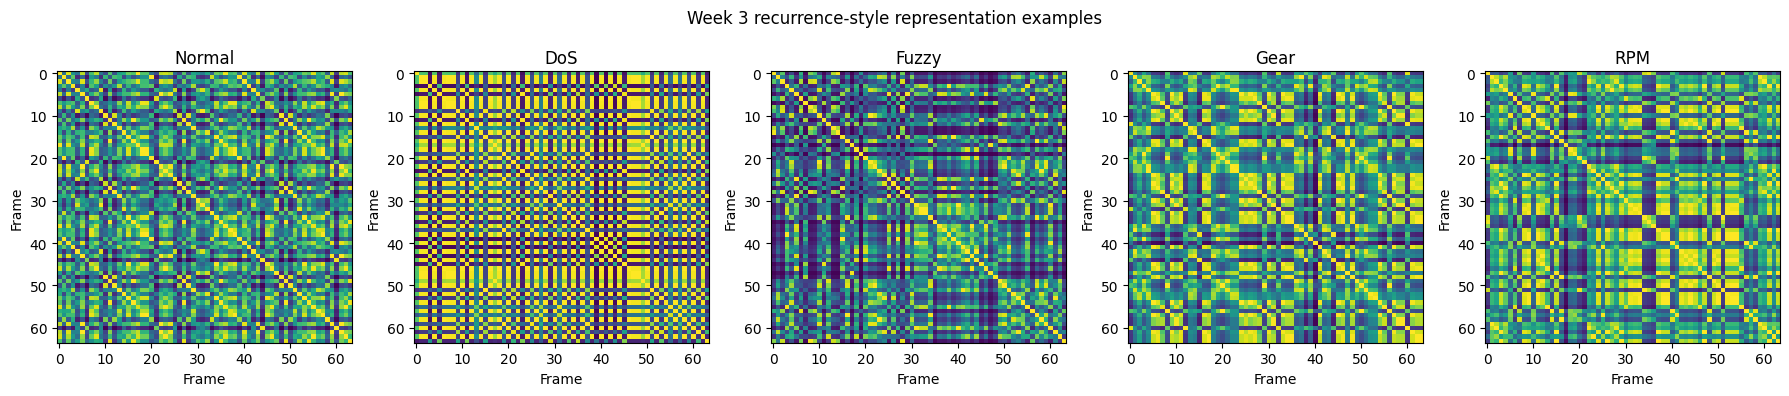

,Class,Example_Index,Image_Shape,Minimum,Maximum,Mean
0,Normal,3,"(64, 64)",0.055175,1.0,0.536148
1,DoS,1,"(64, 64)",0.043789,1.0,0.530326
2,Fuzzy,0,"(64, 64)",0.008408,1.0,0.394540
3,Gear,8,"(64, 64)",0.075000,1.0,0.571171
4,RPM,5,"(64, 64)",0.065873,1.0,0.571235


In [17]:
# 13. Recurrence-style image transformation

def sequence_to_recurrence(
    sequence: np.ndarray,
    gamma: float = 8.0,
) -> np.ndarray:
    '''
    Convert one [64, 11] CAN sequence into a [64, 64] image.

    The compact signal combines CAN ID, DLC, payload mean and timing.
    Pairwise absolute distance is transformed into similarity.
    '''
    sequence = sequence.astype(np.float32)

    signal = (
        0.35 * sequence[:, 0]
        + 0.10 * sequence[:, 1]
        + 0.45 * sequence[:, 2:10].mean(axis=1)
        + 0.10 * sequence[:, 10]
    )

    distance = np.abs(
        signal[:, None] - signal[None, :]
    )

    image = np.exp(-gamma * distance).astype(np.float32)

    assert image.shape == (WINDOW_SIZE, WINDOW_SIZE)
    assert image.min() >= 0
    assert image.max() <= 1

    return image


train_labels = DATA["train"]["labels"]

fig, axes = plt.subplots(
    1,
    len(CLASS_NAMES),
    figsize=(18, 4),
)

recurrence_audit_rows = []

for class_index, class_name in enumerate(CLASS_NAMES):
    example_index = int(
        np.flatnonzero(train_labels == class_index)[0]
    )

    recurrence = sequence_to_recurrence(
        DATA["train"]["sequences"][example_index]
    )

    axes[class_index].imshow(
        recurrence,
        aspect="auto",
    )
    axes[class_index].set_title(class_name)
    axes[class_index].set_xlabel("Frame")
    axes[class_index].set_ylabel("Frame")

    recurrence_audit_rows.append({
        "Class": class_name,
        "Example_Index": example_index,
        "Image_Shape": str(tuple(recurrence.shape)),
        "Minimum": float(recurrence.min()),
        "Maximum": float(recurrence.max()),
        "Mean": float(recurrence.mean()),
    })

fig.suptitle("Week 3 recurrence-style representation examples")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "week03_recurrence_examples.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

recurrence_audit_df = pd.DataFrame(recurrence_audit_rows)
display(recurrence_audit_df)

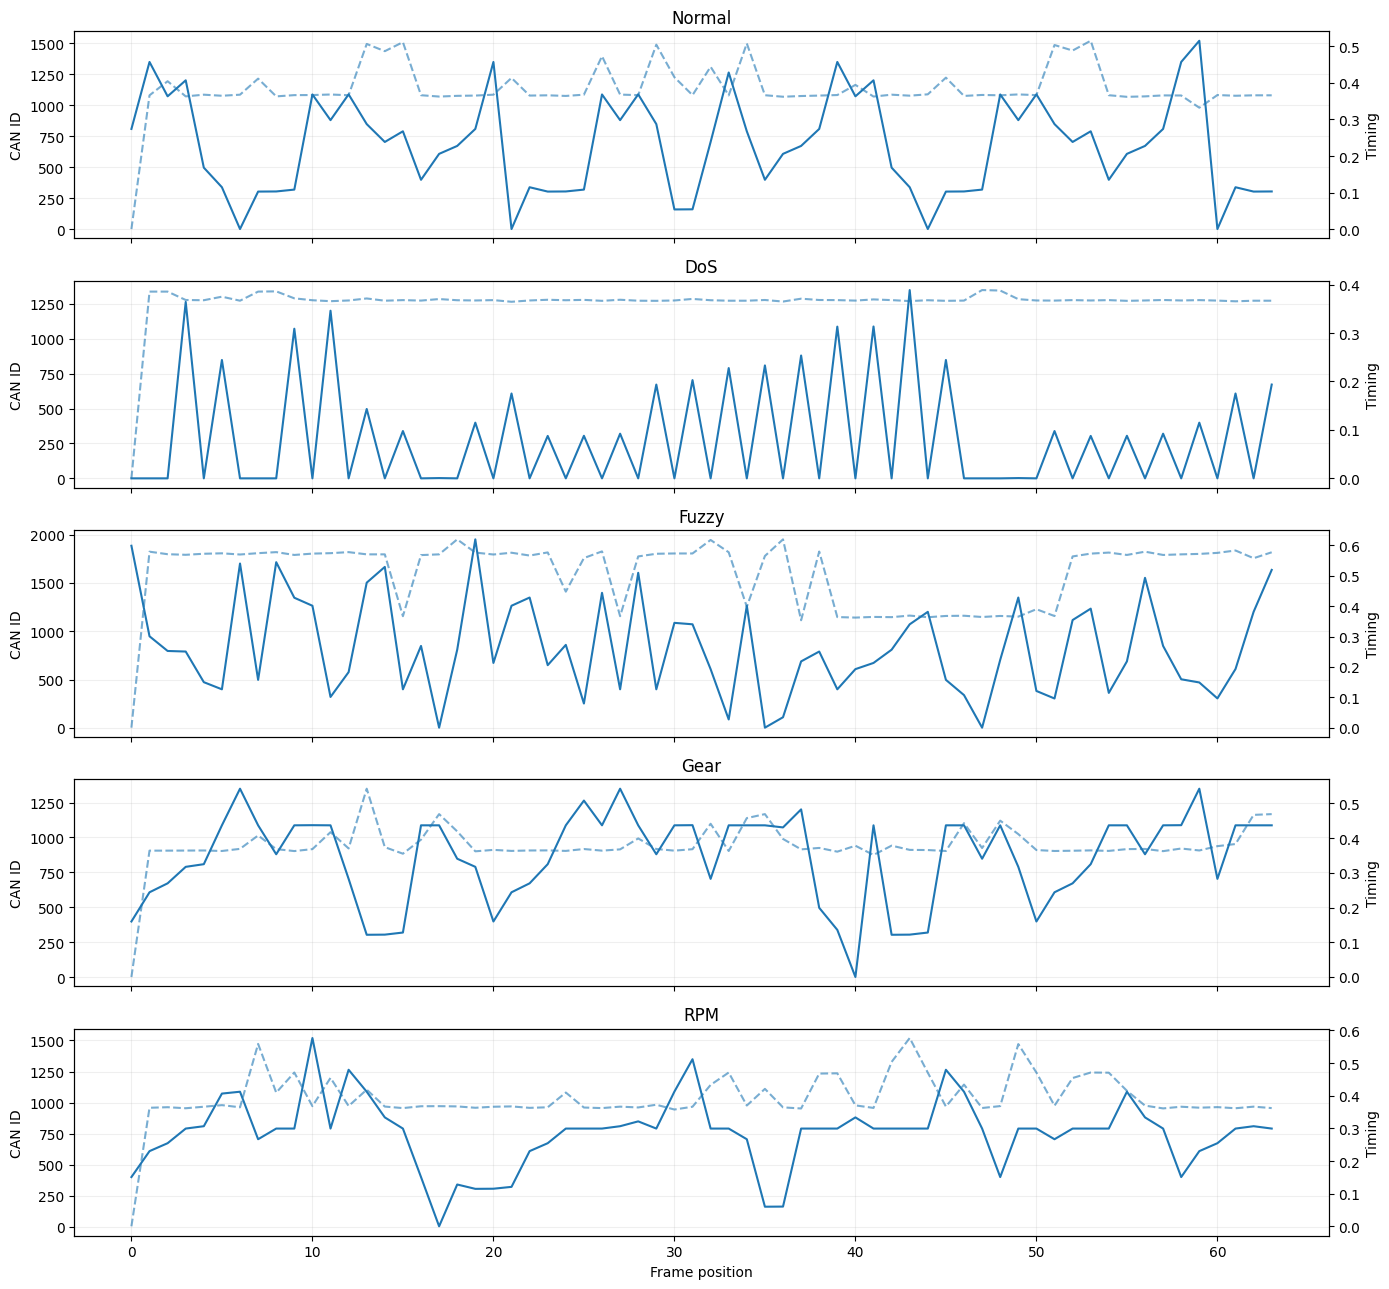

In [18]:
# 14. Inspect one chronological sequence from each class

fig, axes = plt.subplots(
    len(CLASS_NAMES),
    1,
    figsize=(14, 13),
    sharex=True,
)

for class_index, class_name in enumerate(CLASS_NAMES):
    example_index = int(
        np.flatnonzero(train_labels == class_index)[0]
    )
    sequence = DATA["train"]["sequences"][example_index].astype(np.float32)

    can_ids = np.rint(sequence[:, 0] * 2047).astype(int)
    timing = sequence[:, 10]

    axes[class_index].plot(
        np.arange(WINDOW_SIZE),
        can_ids,
        label="CAN ID",
    )
    axes[class_index].set_title(class_name)
    axes[class_index].set_ylabel("CAN ID")
    axes[class_index].grid(alpha=0.2)

    timing_axis = axes[class_index].twinx()
    timing_axis.plot(
        np.arange(WINDOW_SIZE),
        timing,
        linestyle="--",
        alpha=0.6,
        label="Timing",
    )
    timing_axis.set_ylabel("Timing")

axes[-1].set_xlabel("Frame position")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "week03_sequence_examples.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

# Part C — Export Week 3 Evidence

In [19]:
# 15. Export small Week 3 evidence files

split_class_counts.to_csv(
    REPORT_DIR / "week03_split_class_counts.csv",
    index=False,
)

coverage_table.to_csv(
    REPORT_DIR / "week03_class_coverage.csv"
)

chronology_audit_df.to_csv(
    REPORT_DIR / "week03_chronology_audit.csv",
    index=False,
)

overlap_audit_df.to_csv(
    REPORT_DIR / "week03_non_overlap_audit.csv",
    index=False,
)

representation_audit_df.to_csv(
    REPORT_DIR / "week03_representation_audit.csv",
    index=False,
)

feature_dictionary_df.to_csv(
    REPORT_DIR / "week03_feature_dictionary.csv",
    index=False,
)

sequence_channel_df.to_csv(
    REPORT_DIR / "week03_sequence_channels.csv",
    index=False,
)

recurrence_audit_df.to_csv(
    REPORT_DIR / "week03_recurrence_audit.csv",
    index=False,
)

metadata_export = []

for split_name in ["train", "validation", "test"]:
    frame = DATA[split_name]["metadata"].copy()
    frame["split"] = split_name
    metadata_export.append(frame)

metadata_df = pd.concat(
    metadata_export,
    ignore_index=True,
)

metadata_df.to_csv(
    REPORT_DIR / "week03_window_metadata.csv",
    index=False,
)

week3_summary = {
    "project": "AutoSPECTRA",
    "week": 3,
    "scope": (
        "64-frame windowing, source/class chronological split, "
        "leakage controls and model-ready representations"
    ),
    "classes": CLASS_NAMES,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "split_strategy": SPLIT_STRATEGY,
    "split_fractions": {
        "train": TRAIN_FRACTION,
        "validation": VALID_FRACTION,
        "test": TEST_FRACTION,
    },
    "tabular_feature_count": len(FEATURE_NAMES),
    "sequence_shape": [WINDOW_SIZE, 11],
    "recurrence_shape": [WINDOW_SIZE, WINDOW_SIZE],
    "class_coverage_passed": True,
    "chronology_audit_passed": True,
    "non_overlap_audit_passed": True,
    "models_trained": False,
    "next_week": (
        "Logistic Regression, Random Forest, Extra Trees "
        "and XGBoost baseline comparison"
    ),
}

with (
    REPORT_DIR / "week03_summary.json"
).open("w", encoding="utf-8") as handle:
    json.dump(week3_summary, handle, indent=2)

zip_path = Path(
    "/kaggle/working/AutoSPECTRA_Week03_Evidence.zip"
)

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:
    for file_path in OUTPUT_DIR.rglob("*"):
        if file_path.is_file() and file_path != CACHE_FILE:
            archive.write(
                file_path,
                file_path.relative_to(OUTPUT_DIR),
            )

print("=" * 90)
print("AUTOSPECTRA WEEK 3 COMPLETE")
print("=" * 90)
print(json.dumps(week3_summary, indent=2))
print("Evidence ZIP:", zip_path)
print("Models trained in Week 3: No")

AUTOSPECTRA WEEK 3 COMPLETE
{
  "project": "AutoSPECTRA",
  "week": 3,
  "scope": "64-frame windowing, source/class chronological split, leakage controls and model-ready representations",
  "classes": [
    "Normal",
    "DoS",
    "Fuzzy",
    "Gear",
    "RPM"
  ],
  "window_size": 64,
  "stride": 64,
  "split_strategy": "source_class_chronological_v3",
  "split_fractions": {
    "train": 0.7,
    "validation": 0.15,
    "test": 0.15
  },
  "tabular_feature_count": 24,
  "sequence_shape": [
    64,
    11
  ],
  "recurrence_shape": [
    64,
    64
  ],
  "class_coverage_passed": true,
  "chronology_audit_passed": true,
  "non_overlap_audit_passed": true,
  "models_trained": false,
  "next_week": "Logistic Regression, Random Forest, Extra Trees and XGBoost baseline comparison"
}
Evidence ZIP: /kaggle/working/AutoSPECTRA_Week03_Evidence.zip
Models trained in Week 3: No


# Week 3 Completion Summary

## Completed

- Reused the validated Week 2 DLC-aware parser.
- Created non-overlapping 64-frame windows.
- Retained source and original row-position metadata.
- Sampled candidates across the full capture duration.
- Applied source-aware and class-aware chronological partitions.
- Protected the test set from model development.
- Confirmed all five classes in every split.
- Audited chronological boundaries and frame overlap.
- Engineered 24 tabular features.
- Created `64 × 11` sequential inputs.
- Created `64 × 64` recurrence-style images.
- Exported Week 3 data-lineage and validation evidence.

## Critical Limitation

The final balanced samples do not represent natural attack prevalence. In addition, CAN identifiers can act as vehicle-specific shortcuts. Week 4 baseline results must therefore be interpreted as performance on this benchmark rather than universal connected-car performance.

## Week 4 Handover

Week 4 will train and compare:

- Logistic Regression;
- Random Forest;
- Extra Trees;
- XGBoost.

The primary metric will be macro-F1, supported by per-class precision, recall and F1, confusion matrices, ROC-AUC, PR-AUC, false-positive rate, false-negative rate, inference time and feature importance.

## GitHub Information

Recommended path:

```text
notebooks/week03/autospectra_week03_windowing_split_features.ipynb
```

Commit message:

```text
Notebook: add Week 3 windowing split and feature representations
```